<a href="https://colab.research.google.com/github/umair594/Machine-Learning-Projects/blob/main/Wine_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Wine Quality Prediction Project using Machine Learning**

# **Project Overview**

**Project Title**

Wine Quality Prediction using Machine Learning

**Objective**

The goal of this project is to build a Machine Learning model capable of predicting the quality of wine based on its physicochemical properties such as:

Alcohol content

Acidity levels

Sulphates

pH value

Residual sugar

Density

Chlorides

The model classifies wine quality on a scale from 1–10 using supervised learning algorithms.

# **1. Business Understanding**

Problem Statement
**bold text**
Wine manufacturers need a reliable and automated way to evaluate wine quality. Traditional quality assessment depends on human wine tasters, which can be subjective, time-consuming, and expensive.

Machine Learning can help automate this process by predicting wine quality based on measurable chemical properties.

# Business Impact

**This project can help:**

Improve quality control in wine production

Reduce manual testing costs

Ensure consistent product quality

Identify low-quality batches early

Support decision-making in wine manufacturing industries

# **2. Dataset Information**

**Dataset Used**

**Dataset File: WineQT.csv**

The dataset contains physicochemical properties of wine samples and their quality ratings.

**Features in Dataset**

Feature	                                          Description

fixed acidity	                           Tartaric acid amount in wine

volatile acidity	                       Acetic acid amount

citric acid	                             Citric acid level

residual sugar	                         Sugar remaining after fermentation

chlorides	                               Salt amount

free sulfur dioxide	                     Free SO2 amount

total sulfur dioxide	                   Total SO2 amount

density	                                 Density of wine

pH	                                     Acidity/alkalinity

sulphates	                               Potassium sulphate level

alcohol	                                 Alcohol percentage

quality	                                 Wine quality score (Target Variable)

# **3. Project Workflow**

**The project follows the standard Machine Learning lifecycle:**

Import Libraries

Load Dataset

Data Exploration

Data Cleaning

Exploratory Data Analysis (EDA)

Feature Selection

Data Preprocessing

Train-Test Split

Model Building

Model Evaluation

Hyperparameter Tuning

Model Saving

Conclusion

# **4. Import Required Libraries**

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# **5. Load the Dataset**

In [2]:
# Load dataset
wine = pd.read_csv('WineQT.csv')

# Display first 5 rows
print(wine.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

# **6. Explore the Dataset**

**Check Dataset Shape**

In [3]:
print(wine.shape)

(1143, 13)


# **Check Column Names**

In [4]:
print(wine.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')


**Dataset Information**

In [5]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


**Statistical Summary**

In [6]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


**Check Missing Values**

In [7]:
print(wine.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


# **7. Data Cleaning**

**Remove Unnecessary Columns**

In [8]:
# Remove Id column if exists
if 'Id' in wine.columns:
    wine.drop('Id', axis=1, inplace=True)

**Check Duplicate Records**

In [9]:
print(wine.duplicated().sum())

125


**Remove Duplicates**

In [10]:
wine = wine.drop_duplicates()

# **8. Exploratory Data Analysis (EDA)**

**Distribution of Wine Quality**

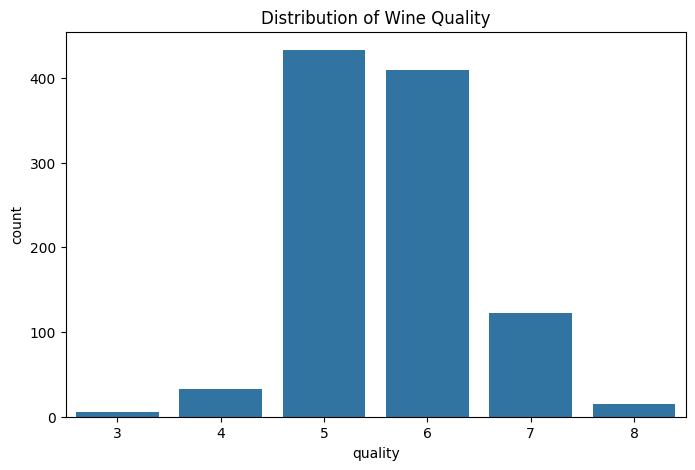

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=wine)
plt.title('Distribution of Wine Quality')
plt.show()

**Correlation Heatmap**

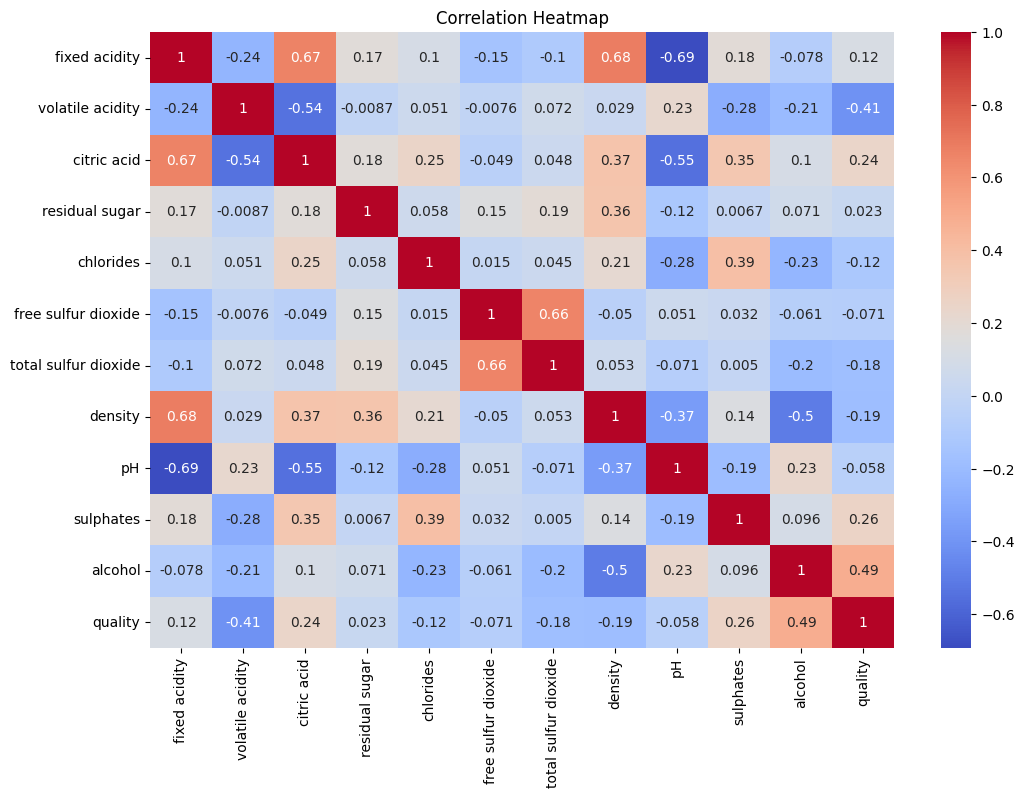

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(wine.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Alcohol vs Quality**

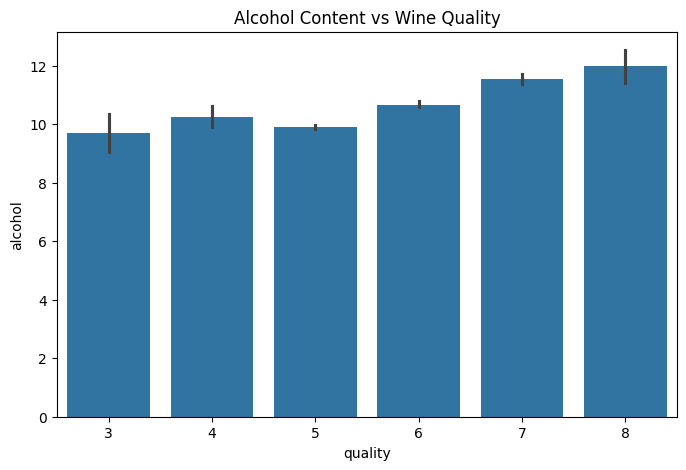

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x='quality', y='alcohol', data=wine)
plt.title('Alcohol Content vs Wine Quality')
plt.show()

**Volatile Acidity vs Quality**

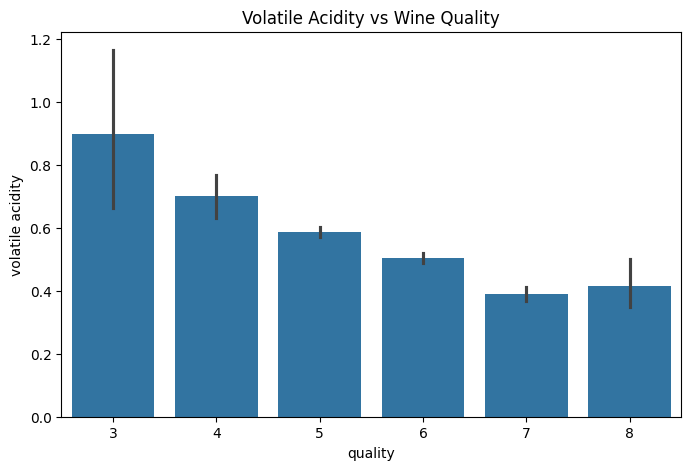

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x='quality', y='volatile acidity', data=wine)
plt.title('Volatile Acidity vs Wine Quality')
plt.show()

# **9. Feature Selection**

**Define Features and Target Variable**

In [15]:
X = wine.drop('quality', axis=1)
y = wine['quality']

# **10. Data Preprocessing**

**Feature Scaling**

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **11. Split Data into Training and Testing Sets**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# **12. Model Building**

**Logistic Regression Model**

In [18]:
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# **13. Model Evaluation**

**Accuracy Score**

In [19]:
lr_accuracy = accuracy_score(y_test, lr_pred)
print('Accuracy:', lr_accuracy)

Accuracy: 0.5343137254901961


**Classification Report**

In [20]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        12
           5       0.62      0.69      0.65        84
           6       0.46      0.57      0.51        74
           7       0.50      0.36      0.42        25
           8       0.00      0.00      0.00         7

    accuracy                           0.53       204
   macro avg       0.26      0.27      0.26       204
weighted avg       0.48      0.53      0.50       204



**Confusion Matrix**

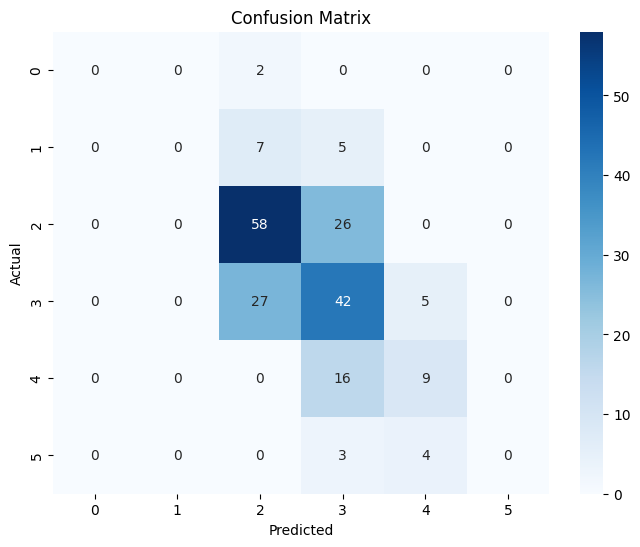

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **14. Random Forest Classifier (Advanced Model)**

**Train Random Forest Model**

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

**Evaluate Random Forest**

In [23]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print('Random Forest Accuracy:', rf_accuracy)

Random Forest Accuracy: 0.5637254901960784


# **15. Feature Importance**

**Visualize Important Features**

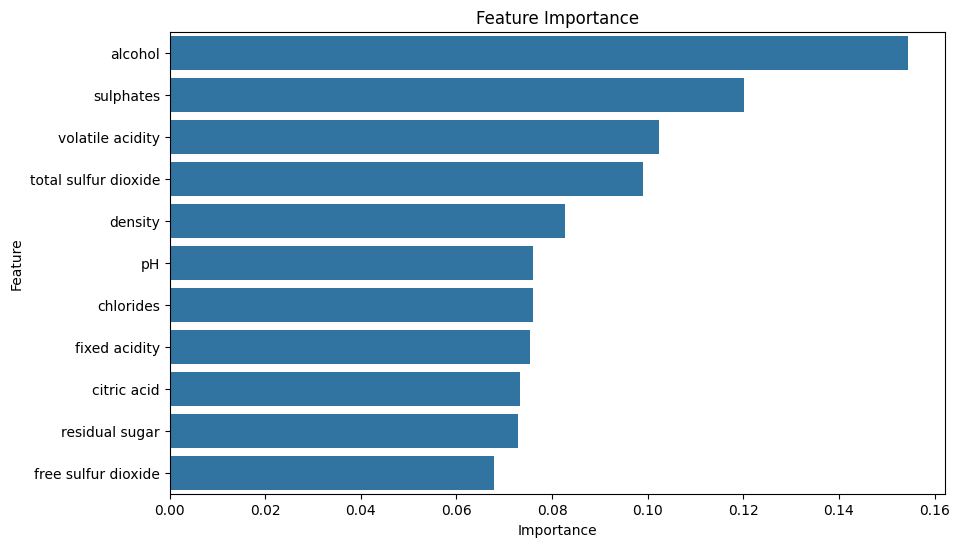

In [24]:
importance = rf_model.feature_importances_
features = X.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance')
plt.show()

# **16. Hyperparameter Tuning (Optional Advanced Step)**

In [25]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


# **17. Save the Model**

**Save Trained Model using Pickle**

In [26]:
import pickle

with open('wine_quality_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

# **18. Load Saved Model**

In [27]:
with open('wine_quality_model.pkl', 'rb') as file:
    model = pickle.load(file)

# **19. Predict on New Data**

In [28]:
sample_data = [[7.4, 0.70, 0.00, 1.9, 0.076,
                11.0, 34.0, 0.9978, 3.51,
                0.56, 9.4]]

sample_scaled = scaler.transform(sample_data)

prediction = model.predict(sample_scaled)

print('Predicted Wine Quality:', prediction)

Predicted Wine Quality: [5]


# **20. Final Conclusion**

**Project Summary**

**In this project, we:**

Built a Wine Quality Prediction system using Machine Learning.
Performed complete data preprocessing and EDA.
Used Logistic Regression and Random Forest algorithms.
Evaluated models using accuracy score, classification report, and confusion matrix.
Identified important chemical properties affecting wine quality.
Saved the trained model for future deployment.